<a href="https://colab.research.google.com/github/williamtb710/semiconductor-yield-anomaly-triage/blob/main/notebooks/02_modeling_triage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 — Rare-failure modeling, operating policy, and triage

## Decision question

Can anonymous process measurements rank rare downstream failures well enough to support a constrained engineering-review queue, and how sensitive is that conclusion to time ordering and model choice?

The output is a triage aid—not a process-control rule, causal model, or physical root-cause diagnosis. Class-weighted model outputs are treated as ranking scores rather than calibrated failure probabilities.

## Analysis specification

- **Primary validation:** first 80% of timestamp-ordered records for training; final 20% held out.
- **Sensitivity validation:** fixed-seed 80/20 stratified-random split.
- **Reference:** always predict pass.
- **Models:** class-weighted regularized logistic regression and one constrained random forest.
- **Operating point:** review the top 10% of held-out records by score.
- **Primary discrimination metric:** average precision and the precision-recall curve.
- **Uncertainty:** stratified bootstrap intervals on held-out results.

All preprocessing is fit inside each training partition through a scikit-learn `Pipeline`. See the official documentation for [`Pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html), [`average_precision_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html), and [decision-threshold tradeoffs](https://scikit-learn.org/stable/modules/classification_threshold.html).

In [1]:
from __future__ import annotations

from collections import Counter
from datetime import datetime, timezone
from hashlib import sha256
from pathlib import Path
from urllib.request import urlretrieve
from zipfile import ZIP_DEFLATED, ZipFile
import json
import sys

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    from IPython.display import display
except ImportError:
    display = print

RANDOM_STATE = 42
REVIEW_BUDGET = 0.10
N_BOOTSTRAPS = 1000
N_STABILITY_BOOTSTRAPS = 20

print(f"Python {sys.version.split()[0]} | pandas {pd.__version__} | scikit-learn {sklearn.__version__} | Matplotlib {matplotlib.__version__}")

Python 3.13.15 | pandas 2.2.3 | scikit-learn 1.6.1 | Matplotlib 3.10.0


## 1. Source-controlled acquisition

The dataset is reacquired from UCI so this notebook is independently reproducible. The expected archive digest and structural assertions match the data audit.

In [2]:
UCI_ARCHIVE_URL = "https://archive.ics.uci.edu/static/public/179/secom.zip"
EXPECTED_ARCHIVE_SHA256 = "eea568baf3c2229096d7d294cf0b096b5502bd96d92c0b80a65b84714059be8e"
REQUIRED_MEMBERS = {"secom.data", "secom_labels.data", "secom.names"}

PROJECT_ROOT = Path.cwd()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
REPORT_DIR = PROJECT_ROOT / "reports"
FIGURE_DIR = REPORT_DIR / "figures"
RAW_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

def file_sha256(path: Path) -> str:
    digest = sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

archive_path = RAW_DIR / "secom.zip"
if not archive_path.exists() or file_sha256(archive_path) != EXPECTED_ARCHIVE_SHA256:
    urlretrieve(UCI_ARCHIVE_URL, archive_path)
if file_sha256(archive_path) != EXPECTED_ARCHIVE_SHA256:
    raise RuntimeError("UCI archive hash changed; inspect source version before continuing.")

with ZipFile(archive_path) as archive:
    if not REQUIRED_MEMBERS.issubset(archive.namelist()):
        raise RuntimeError("Expected UCI source files are missing.")
    for member in sorted(REQUIRED_MEMBERS):
        (RAW_DIR / member).write_bytes(archive.read(member))

X = pd.read_csv(RAW_DIR / "secom.data", sep=r"\s+", header=None, na_values=["NaN"], dtype=float)
X.columns = [f"feature_{index:03d}" for index in range(X.shape[1])]
labels = pd.read_csv(
    RAW_DIR / "secom_labels.data",
    sep=r"\s+",
    header=None,
    names=["source_label", "timestamp_text"],
    quotechar='"',
)
labels["timestamp"] = pd.to_datetime(labels["timestamp_text"], format="%d/%m/%Y %H:%M:%S", errors="raise")
y = (labels["source_label"].astype(int) == 1).astype(int)

assert X.shape == (1567, 590)
assert y.value_counts().sort_index().to_dict() == {0: 1463, 1: 104}
assert labels["timestamp"].is_monotonic_increasing
print(f"Loaded {X.shape[0]:,} records, {X.shape[1]} raw numeric features, {int(y.sum())} failures.")

Loaded 1,567 records, 590 raw numeric features, 104 failures.


## 2. Validation designs

The chronological holdout is the primary result because it preserves the direction of time. The random split is not a second chance to choose a winner; it tests how strongly conclusions depend on assuming exchangeable observations.

In [3]:
all_indices = np.arange(len(X))
chronological_cut = int(np.floor(0.80 * len(X)))
chronological_train = all_indices[:chronological_cut]
chronological_test = all_indices[chronological_cut:]
random_train, random_test = train_test_split(
    all_indices,
    test_size=len(chronological_test),
    stratify=y,
    random_state=RANDOM_STATE,
)

SPLITS = {
    "Chronological": (chronological_train, chronological_test),
    "Stratified random": (random_train, random_test),
}

split_rows = []
for split_name, (train_idx, test_idx) in SPLITS.items():
    split_rows.append(
        {
            "split": split_name,
            "train_records": len(train_idx),
            "train_failures": int(y.iloc[train_idx].sum()),
            "test_records": len(test_idx),
            "test_failures": int(y.iloc[test_idx].sum()),
            "test_prevalence": float(y.iloc[test_idx].mean()),
            "test_start": labels["timestamp"].iloc[test_idx].min(),
            "test_end": labels["timestamp"].iloc[test_idx].max(),
        }
    )
split_summary = pd.DataFrame(split_rows)
display(split_summary)

,split,train_records,train_failures,test_records,test_failures,test_prevalence,test_start,test_end
0,Chronological,1253,87,314,17,0.054140,2008-10-02 20:54:00,2008-10-17 06:07:00
1,Stratified random,1253,83,314,21,0.066879,2008-07-19 12:32:00,2008-10-17 06:01:00


## 3. Training-only preprocessing and fixed models

The custom filter learns which columns are constant or more than 50% missing from the training partition only. Median imputation and missingness indicators are also learned inside the pipeline. Logistic inputs are standardized; the forest does not require scaling.

Hyperparameters are fixed rather than selected by repeatedly consulting either holdout.

In [4]:
class TrainingFeatureFilter(BaseEstimator, TransformerMixin):
    def __init__(self, max_missing_rate: float = 0.50):
        self.max_missing_rate = max_missing_rate

    def fit(self, X_frame: pd.DataFrame, y_values=None):
        missing_rate = X_frame.isna().mean()
        unique_non_null = X_frame.nunique(dropna=True)
        keep_mask = (missing_rate <= self.max_missing_rate) & (unique_non_null > 1)
        self.features_to_keep_ = X_frame.columns[keep_mask].tolist()
        self.n_features_in_ = X_frame.shape[1]
        return self

    def transform(self, X_frame: pd.DataFrame):
        return X_frame.loc[:, self.features_to_keep_]

    def get_feature_names_out(self, input_features=None):
        return np.asarray(self.features_to_keep_, dtype=object)

def make_logistic_pipeline() -> Pipeline:
    return Pipeline(
        [
            ("feature_filter", TrainingFeatureFilter(max_missing_rate=0.50)),
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
            ("scaler", StandardScaler()),
            (
                "model",
                LogisticRegression(
                    C=0.10,
                    class_weight="balanced",
                    solver="liblinear",
                    max_iter=3000,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )

def make_forest_pipeline() -> Pipeline:
    return Pipeline(
        [
            ("feature_filter", TrainingFeatureFilter(max_missing_rate=0.50)),
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=500,
                    max_depth=6,
                    min_samples_leaf=8,
                    max_features="sqrt",
                    class_weight="balanced_subsample",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    )

MODEL_FACTORIES = {
    "Regularized logistic": make_logistic_pipeline,
    "Constrained random forest": make_forest_pipeline,
}

## 4. Operating-policy evaluation

The top-10% rule fixes review capacity without using held-out labels to tune a threshold. This makes the output directly interpretable: how many failures are captured when engineers can inspect roughly 32 of 314 records?

In [5]:
def apply_review_budget(y_true: np.ndarray, scores: np.ndarray, budget: float = REVIEW_BUDGET):
    n_review = max(1, int(np.ceil(budget * len(y_true))))
    ranked = np.argsort(-scores, kind="stable")
    reviewed = np.zeros(len(y_true), dtype=int)
    reviewed[ranked[:n_review]] = 1
    threshold = float(scores[ranked[n_review - 1]])
    tn, fp, fn, tp = confusion_matrix(y_true, reviewed, labels=[0, 1]).ravel()
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    false_positive_rate = fp / (fp + tn) if (fp + tn) else 0.0
    prevalence = float(np.mean(y_true))
    return reviewed, {
        "review_n": n_review,
        "score_cutoff": threshold,
        "precision_at_budget": precision,
        "recall_at_budget": recall,
        "false_positive_rate_at_budget": false_positive_rate,
        "lift_at_budget": precision / prevalence if prevalence else np.nan,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

baseline_rows = []
model_rows = []
fitted_models = {}
score_store = {}
review_store = {}

for split_name, (train_idx, test_idx) in SPLITS.items():
    y_train = y.iloc[train_idx].to_numpy()
    y_test = y.iloc[test_idx].to_numpy()
    constant_scores = np.repeat(y_train.mean(), len(test_idx))
    baseline_rows.append(
        {
            "split": split_name,
            "test_prevalence": y_test.mean(),
            "always_pass_accuracy": accuracy_score(y_test, np.zeros_like(y_test)),
            "always_pass_failure_recall": 0.0,
            "constant_score_average_precision": average_precision_score(y_test, constant_scores),
        }
    )

    for model_name, factory in MODEL_FACTORIES.items():
        pipeline = factory()
        pipeline.fit(X.iloc[train_idx], y_train)
        scores = pipeline.predict_proba(X.iloc[test_idx])[:, 1]
        default_prediction = (scores >= 0.50).astype(int)
        reviewed, budget_metrics = apply_review_budget(y_test, scores)
        row = {
            "split": split_name,
            "model": model_name,
            "train_n": len(train_idx),
            "test_n": len(test_idx),
            "test_failures": int(y_test.sum()),
            "test_prevalence": float(y_test.mean()),
            "retained_raw_features": len(pipeline.named_steps["feature_filter"].features_to_keep_),
            "average_precision": average_precision_score(y_test, scores),
            "roc_auc": roc_auc_score(y_test, scores),
            "accuracy_at_0_5": accuracy_score(y_test, default_prediction),
            "balanced_accuracy_at_0_5": balanced_accuracy_score(y_test, default_prediction),
            **budget_metrics,
        }
        model_rows.append(row)
        key = (split_name, model_name)
        fitted_models[key] = pipeline
        score_store[key] = scores
        review_store[key] = reviewed

baseline_results = pd.DataFrame(baseline_rows)
model_results = pd.DataFrame(model_rows)
baseline_display = baseline_results.copy()
for column in ["test_prevalence", "always_pass_accuracy", "always_pass_failure_recall"]:
    baseline_display[column] = baseline_display[column].map(lambda value: f"{value:.2%}")
baseline_display["constant_score_average_precision"] = baseline_display["constant_score_average_precision"].map(lambda value: f"{value:.3f}")
display(baseline_display)
display(model_results[["split", "model", "average_precision", "roc_auc", "review_n", "precision_at_budget", "recall_at_budget", "lift_at_budget", "tp", "fp", "fn", "tn"]])

,split,test_prevalence,always_pass_accuracy,always_pass_failure_recall,constant_score_average_precision
0,Chronological,5.41%,94.59%,0.00%,0.054
1,Stratified random,6.69%,93.31%,0.00%,0.067


,split,model,average_precision,roc_auc,review_n,precision_at_budget,recall_at_budget,lift_at_budget,tp,fp,fn,tn
0,Chronological,Regularized logistic,0.205633,0.788473,32,0.15625,0.294118,2.886029,5,27,12,270
1,Chronological,Constrained random forest,0.075453,0.562686,32,0.06250,0.117647,1.154412,2,30,15,267
2,Stratified random,Regularized logistic,0.123768,0.611572,32,0.12500,0.190476,1.869048,4,28,17,265
3,Stratified random,Constrained random forest,0.189349,0.765480,32,0.21875,0.333333,3.270833,7,25,14,268


### Reading the result

Accuracy looks strong for the always-pass reference because failures are rare, yet its failure recall is zero. Average precision should be read relative to the failure prevalence in the same holdout. The budget table converts ranking quality into engineering workload and captured failures.

ROC-AUC remains useful context, but it can appear favorable while the actionable top of the ranking still contains many false alarms.

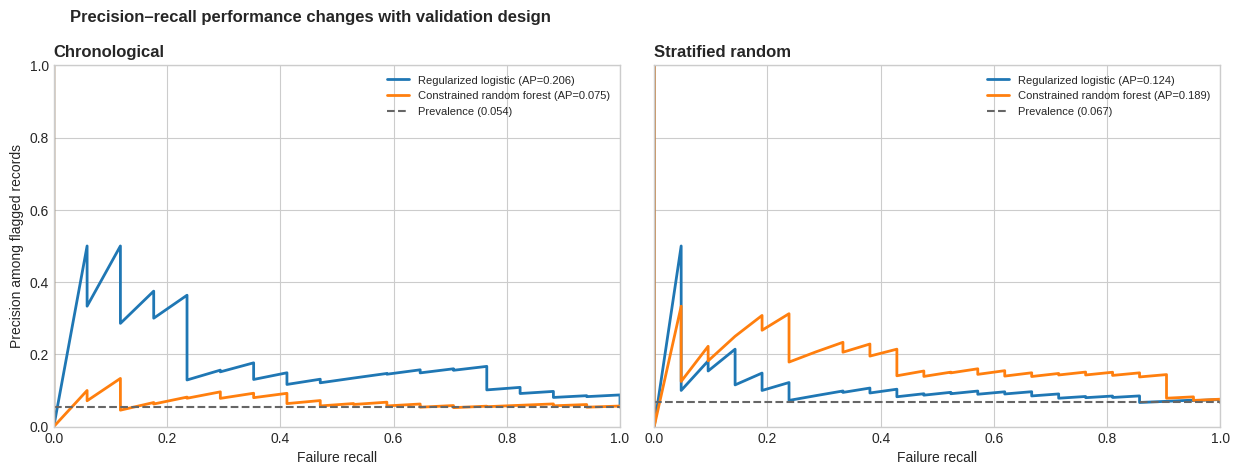

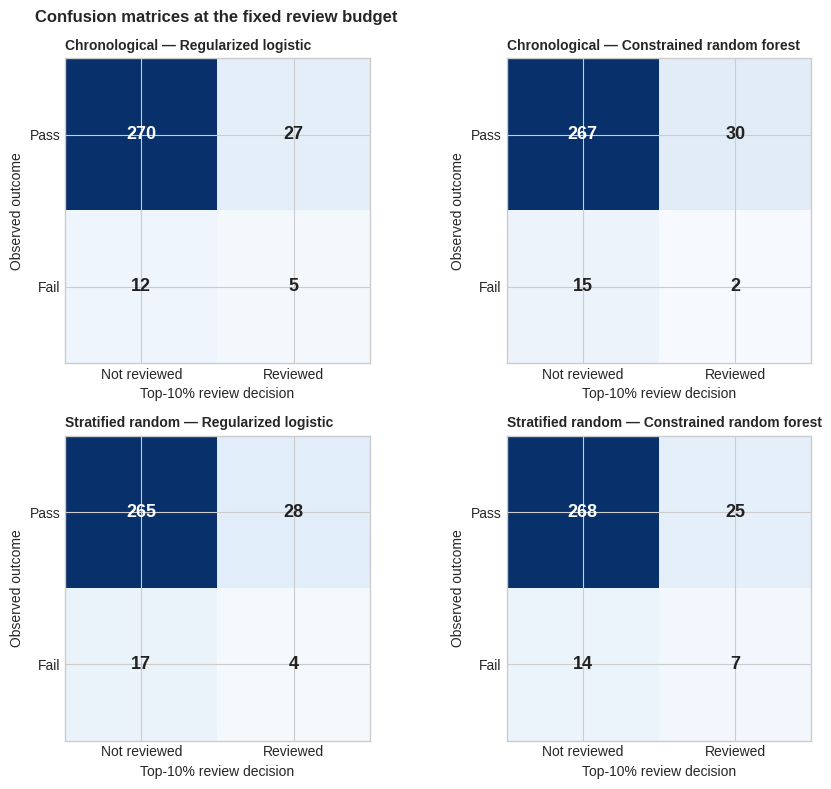

In [6]:
plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), sharey=True)
for axis, (split_name, (_, test_idx)) in zip(axes, SPLITS.items()):
    y_test = y.iloc[test_idx].to_numpy()
    for model_name in MODEL_FACTORIES:
        scores = score_store[(split_name, model_name)]
        precision, recall, _ = precision_recall_curve(y_test, scores)
        ap = average_precision_score(y_test, scores)
        axis.plot(recall, precision, linewidth=2, label=f"{model_name} (AP={ap:.3f})")
    axis.axhline(y_test.mean(), color="#666666", linestyle="--", label=f"Prevalence ({y_test.mean():.3f})")
    axis.set_title(split_name, loc="left", fontweight="bold")
    axis.set_xlabel("Failure recall")
    axis.set_xlim(0, 1)
    axis.set_ylim(0, 1)
    axis.legend(fontsize=8, loc="upper right")
axes[0].set_ylabel("Precision among flagged records")
fig.suptitle("Precision–recall performance changes with validation design", x=0.06, ha="left", fontweight="bold")
fig.tight_layout()
pr_curve_path = FIGURE_DIR / "precision_recall_comparison.png"
fig.savefig(pr_curve_path, dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(9.2, 8.0))
for axis, ((split_name, model_name), reviewed) in zip(axes.flat, review_store.items()):
    test_idx = SPLITS[split_name][1]
    matrix = confusion_matrix(y.iloc[test_idx], reviewed, labels=[0, 1])
    axis.imshow(matrix, cmap="Blues", vmin=0, vmax=matrix.max())
    for row in range(2):
        for column in range(2):
            text_color = "white" if matrix[row, column] > matrix.max() / 2 else "#222222"
            axis.text(column, row, f"{matrix[row, column]:,}", ha="center", va="center", fontsize=13, fontweight="bold", color=text_color)
    axis.set_xticks([0, 1], labels=["Not reviewed", "Reviewed"])
    axis.set_yticks([0, 1], labels=["Pass", "Fail"])
    axis.set_title(f"{split_name} — {model_name}", fontsize=10, loc="left", fontweight="bold")
    axis.set_xlabel("Top-10% review decision")
    axis.set_ylabel("Observed outcome")
fig.suptitle("Confusion matrices at the fixed review budget", x=0.08, ha="left", fontweight="bold")
fig.tight_layout()
confusion_path = FIGURE_DIR / "review_budget_confusion_matrices.png"
fig.savefig(confusion_path, dpi=180, bbox_inches="tight")
plt.show()

## 5. Sampling uncertainty

Each holdout contains few failures, so point estimates are fragile. The bootstrap preserves the observed positive and negative counts while resampling records within each class. These intervals describe sampling variability conditional on this dataset and split; they do not cover cross-fab or process-regime uncertainty.

In [7]:
def stratified_bootstrap_metrics(y_true: np.ndarray, scores: np.ndarray, seed: int):
    rng = np.random.default_rng(seed)
    positive = np.flatnonzero(y_true == 1)
    negative = np.flatnonzero(y_true == 0)
    rows = []
    for _ in range(N_BOOTSTRAPS):
        sampled = np.concatenate(
            [
                rng.choice(positive, size=len(positive), replace=True),
                rng.choice(negative, size=len(negative), replace=True),
            ]
        )
        rng.shuffle(sampled)
        sampled_y = y_true[sampled]
        sampled_scores = scores[sampled]
        _, budget = apply_review_budget(sampled_y, sampled_scores)
        rows.append(
            {
                "average_precision": average_precision_score(sampled_y, sampled_scores),
                "precision_at_budget": budget["precision_at_budget"],
                "recall_at_budget": budget["recall_at_budget"],
            }
        )
    return pd.DataFrame(rows)

interval_rows = []
for offset, ((split_name, model_name), scores) in enumerate(score_store.items()):
    test_idx = SPLITS[split_name][1]
    boot = stratified_bootstrap_metrics(y.iloc[test_idx].to_numpy(), scores, RANDOM_STATE + offset)
    for metric in boot.columns:
        low, median, high = boot[metric].quantile([0.025, 0.50, 0.975])
        interval_rows.append(
            {
                "split": split_name,
                "model": model_name,
                "metric": metric,
                "bootstrap_low_95": low,
                "bootstrap_median": median,
                "bootstrap_high_95": high,
            }
        )
bootstrap_intervals = pd.DataFrame(interval_rows)
display(bootstrap_intervals)

,split,model,metric,bootstrap_low_95,bootstrap_median,bootstrap_high_95
0,Chronological,Regularized logistic,average_precision,0.107978,0.221231,0.423958
1,Chronological,Regularized logistic,precision_at_budget,0.031250,0.156250,0.281250
2,Chronological,Regularized logistic,recall_at_budget,0.058824,0.294118,0.529412
3,Chronological,Constrained random forest,average_precision,0.051183,0.083931,0.157151
4,Chronological,Constrained random forest,precision_at_budget,0.000000,0.062500,0.156250
5,Chronological,Constrained random forest,recall_at_budget,0.000000,0.117647,0.294118
6,Stratified random,Regularized logistic,average_precision,0.075639,0.136648,0.273957
7,Stratified random,Regularized logistic,precision_at_budget,0.031250,0.125000,0.250000
8,Stratified random,Regularized logistic,recall_at_budget,0.047619,0.190476,0.380952
9,Stratified random,Constrained random forest,average_precision,0.128398,0.207395,0.358232


## 6. Logistic associations and stability

Logistic coefficients are comparable because transformed inputs are standardized. A positive coefficient raises the model score; a negative coefficient lowers it. Missingness indicators are retained as separate transformed inputs.

The stability table repeatedly resamples the chronological training partition, refits the entire pipeline, and records which transformed inputs enter the top 15 by absolute coefficient. Selection frequency is a caution flag—not proof of physical relevance.

,transformed_feature,coefficient,absolute_coefficient,direction
0,feature_059,0.926922,0.926922,raises score
1,feature_056,0.734854,0.734854,raises score
2,feature_132,-0.489993,0.489993,lowers score
3,feature_367,-0.398007,0.398007,lowers score
4,feature_205,0.380723,0.380723,raises score
5,feature_129,0.366484,0.366484,raises score
6,feature_060,0.357591,0.357591,raises score
7,feature_067,-0.351987,0.351987,lowers score
8,feature_071,0.348469,0.348469,raises score
9,feature_485,-0.338739,0.338739,lowers score


,transformed_feature,top_15_selections,selection_frequency
0,feature_059,20,1.00
1,feature_056,16,0.80
2,feature_367,11,0.55
3,feature_132,10,0.50
4,feature_485,10,0.50
5,feature_021,7,0.35
6,feature_460,7,0.35
7,feature_038,6,0.30
8,feature_040,6,0.30
9,feature_102,6,0.30


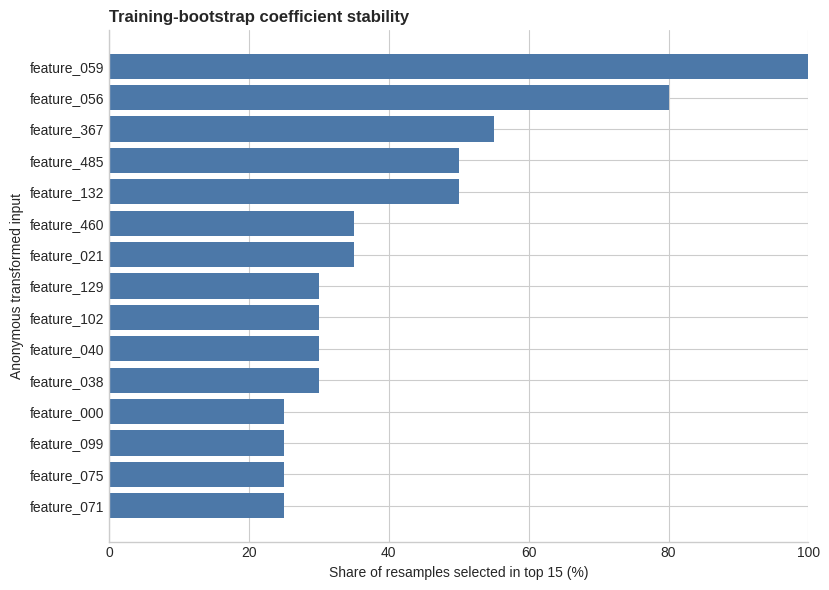

In [8]:
def logistic_coefficient_table(pipeline: Pipeline) -> pd.DataFrame:
    selected = pipeline.named_steps["feature_filter"].get_feature_names_out()
    transformed_names = pipeline.named_steps["imputer"].get_feature_names_out(selected)
    coefficients = pipeline.named_steps["model"].coef_.ravel()
    table = pd.DataFrame({"transformed_feature": transformed_names, "coefficient": coefficients})
    table["absolute_coefficient"] = table["coefficient"].abs()
    table["direction"] = np.where(table["coefficient"] >= 0, "raises score", "lowers score")
    return table.sort_values("absolute_coefficient", ascending=False).reset_index(drop=True)

chronological_logistic = fitted_models[("Chronological", "Regularized logistic")]
coefficient_table = logistic_coefficient_table(chronological_logistic)
display(coefficient_table.head(20))

rng = np.random.default_rng(RANDOM_STATE)
train_idx = chronological_train
train_y = y.iloc[train_idx].to_numpy()
positive_positions = np.flatnonzero(train_y == 1)
negative_positions = np.flatnonzero(train_y == 0)
selection_counter = Counter()

for bootstrap_number in range(N_STABILITY_BOOTSTRAPS):
    sampled_positions = np.concatenate(
        [
            rng.choice(positive_positions, size=len(positive_positions), replace=True),
            rng.choice(negative_positions, size=len(negative_positions), replace=True),
        ]
    )
    rng.shuffle(sampled_positions)
    sampled_global_indices = train_idx[sampled_positions]
    bootstrap_pipeline = make_logistic_pipeline()
    bootstrap_pipeline.fit(X.iloc[sampled_global_indices], y.iloc[sampled_global_indices])
    top_names = logistic_coefficient_table(bootstrap_pipeline).head(15)["transformed_feature"]
    selection_counter.update(top_names.tolist())

coefficient_stability = pd.DataFrame(
    [
        {
            "transformed_feature": name,
            "top_15_selections": count,
            "selection_frequency": count / N_STABILITY_BOOTSTRAPS,
        }
        for name, count in selection_counter.items()
    ]
).sort_values(["selection_frequency", "transformed_feature"], ascending=[False, True]).reset_index(drop=True)
display(coefficient_stability.head(20))

plot_stability = coefficient_stability.head(15).sort_values("selection_frequency")
fig, ax = plt.subplots(figsize=(8.4, 6.0))
ax.barh(plot_stability["transformed_feature"], plot_stability["selection_frequency"] * 100, color="#4C78A8")
ax.set_title("Training-bootstrap coefficient stability", loc="left", fontweight="bold")
ax.set_xlabel("Share of resamples selected in top 15 (%)")
ax.set_ylabel("Anonymous transformed input")
ax.set_xlim(0, 100)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
stability_path = FIGURE_DIR / "coefficient_stability.png"
fig.savefig(stability_path, dpi=180, bbox_inches="tight")
plt.show()

## 7. Record-level triage view

The table ranks the chronological holdout by logistic score. `top_positive_associations` lists the transformed anonymous inputs with the largest positive contribution to that record's linear score. These are explanations of model behavior, not physical diagnoses.

In [9]:
chronological_scores = score_store[("Chronological", "Regularized logistic")]
chronological_reviewed = review_store[("Chronological", "Regularized logistic")]
chronological_test_X = X.iloc[chronological_test]

filtered_test = chronological_logistic.named_steps["feature_filter"].transform(chronological_test_X)
imputed_test = chronological_logistic.named_steps["imputer"].transform(filtered_test)
scaled_test = chronological_logistic.named_steps["scaler"].transform(imputed_test)
coefficients = chronological_logistic.named_steps["model"].coef_.ravel()
selected = chronological_logistic.named_steps["feature_filter"].get_feature_names_out()
transformed_names = chronological_logistic.named_steps["imputer"].get_feature_names_out(selected)
contributions = scaled_test * coefficients

def top_positive_associations(row: np.ndarray, count: int = 3) -> str:
    top_positions = np.argsort(-row)[:count]
    return "; ".join(f"{transformed_names[position]} ({row[position]:+.2f})" for position in top_positions)

triage = pd.DataFrame(
    {
        "record_id": [f"record_{index:04d}" for index in chronological_test],
        "source_row": chronological_test,
        "timestamp": labels["timestamp"].iloc[chronological_test].to_numpy(),
        "observed_outcome": np.where(y.iloc[chronological_test].to_numpy() == 1, "fail", "pass"),
        "model_score_uncalibrated": chronological_scores,
        "review_at_10pct_budget": chronological_reviewed.astype(bool),
        "top_positive_associations": [top_positive_associations(row) for row in contributions],
    }
)
triage["score_rank"] = triage["model_score_uncalibrated"].rank(method="first", ascending=False).astype(int)
triage = triage.sort_values("score_rank").reset_index(drop=True)
display(triage.head(15))

,record_id,source_row,timestamp,observed_outcome,model_score_uncalibrated,review_at_10pct_budget,top_positive_associations,score_rank
0,record_1397,1397,2008-10-07 11:16:00,pass,0.999114,True,feature_205 (+3.25); feature_201 (+2.91); feat...,1
1,record_1400,1400,2008-10-07 13:10:00,fail,0.987343,True,feature_348 (+2.88); feature_075 (+1.80); feat...,2
2,record_1467,1467,2008-10-12 01:50:00,pass,0.982575,True,feature_071 (+0.78); feature_060 (+0.69); feat...,3
3,record_1519,1519,2008-10-15 02:42:00,fail,0.967169,True,feature_099 (+4.84); feature_460 (+0.94); feat...,4
4,record_1257,1257,2008-10-02 22:33:00,pass,0.925377,True,feature_071 (+1.36); feature_132 (+1.12); feat...,5
5,record_1536,1536,2008-10-15 17:19:00,pass,0.919524,True,feature_388 (+5.94); feature_522 (+1.05); feat...,6
6,record_1346,1346,2008-10-06 05:24:00,pass,0.886493,True,feature_588 (+1.65); feature_071 (+1.29); feat...,7
7,record_1343,1343,2008-10-06 03:57:00,fail,0.861440,True,feature_132 (+1.24); feature_071 (+0.95); feat...,8
8,record_1460,1460,2008-10-11 08:27:00,pass,0.834609,True,feature_071 (+0.66); feature_143 (+0.57); feat...,9
9,record_1385,1385,2008-10-07 03:39:00,pass,0.783403,True,feature_331 (+2.11); feature_467 (+1.17); feat...,10


## 8. Monitoring and simulated shift

Observed monitoring views compare weekly failure prevalence and row-level missingness, then quantify train-to-test feature shift using training medians and standard deviations. The intervention below is explicitly simulated: one anonymous input is shifted upward by one training standard deviation to demonstrate score-distribution monitoring.

,feature,standardized_mean_shift,absolute_standardized_mean_shift,missing_rate_change
0,feature_140,409.205693,409.205693,0.016706
1,feature_275,328.348776,328.348776,0.016706
2,feature_004,37.630372,37.630372,0.016706
3,feature_007,-1.432985,1.432985,0.000783
4,feature_132,-1.072214,1.072214,0.005564
5,feature_056,-1.068022,1.068022,-0.003192
6,feature_417,0.925802,0.925802,0.006369
7,feature_316,0.847869,0.847869,-0.000798
8,feature_144,0.837362,0.837362,0.006369
9,feature_070,0.832981,0.832981,-0.004789


,scenario,shifted_feature,mean_model_score,records_at_or_above_original_cutoff
0,Observed chronological holdout,none,0.116894,32
1,Simulated +1 training SD shift,feature_059,0.182796,56


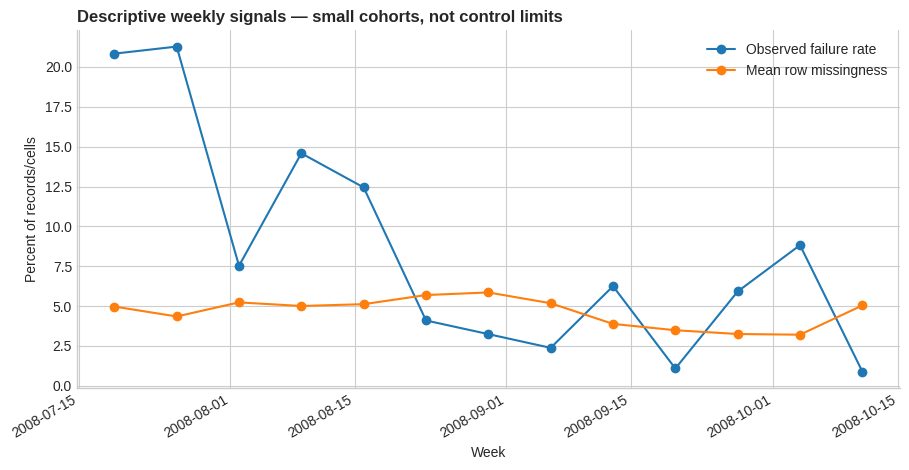

In [10]:
monitoring_frame = pd.DataFrame(
    {
        "timestamp": labels["timestamp"],
        "is_fail": y,
        "row_missing_rate": X.isna().mean(axis=1),
    }
).set_index("timestamp")
weekly_monitoring = monitoring_frame.resample("7D").agg(
    records=("is_fail", "size"),
    failures=("is_fail", "sum"),
    failure_rate=("is_fail", "mean"),
    mean_row_missing_rate=("row_missing_rate", "mean"),
).reset_index()

retained_features = chronological_logistic.named_steps["feature_filter"].features_to_keep_
train_raw = X.iloc[chronological_train][retained_features]
test_raw = X.iloc[chronological_test][retained_features]
train_medians = train_raw.median()
train_filled = train_raw.fillna(train_medians)
test_filled = test_raw.fillna(train_medians)
train_standard_deviation = train_filled.std(ddof=0).replace(0, np.nan)
standardized_mean_shift = (test_filled.mean() - train_filled.mean()) / train_standard_deviation
missingness_shift = test_raw.isna().mean() - train_raw.isna().mean()
drift_summary = pd.DataFrame(
    {
        "feature": retained_features,
        "standardized_mean_shift": standardized_mean_shift.to_numpy(),
        "absolute_standardized_mean_shift": standardized_mean_shift.abs().to_numpy(),
        "missing_rate_change": missingness_shift.to_numpy(),
    }
).sort_values("absolute_standardized_mean_shift", ascending=False).reset_index(drop=True)
display(drift_summary.head(15))

source_coefficient_rows = coefficient_table[~coefficient_table["transformed_feature"].str.startswith("missingindicator_")]
simulated_feature = source_coefficient_rows.iloc[0]["transformed_feature"]
simulated_scale = float(train_raw[simulated_feature].std(skipna=True))
simulated_test = chronological_test_X.copy()
simulated_test.loc[simulated_test[simulated_feature].notna(), simulated_feature] += simulated_scale
simulated_scores = chronological_logistic.predict_proba(simulated_test)[:, 1]
original_cutoff = float(
    model_results.query("split == 'Chronological' and model == 'Regularized logistic'")["score_cutoff"].iloc[0]
)
simulated_shift_summary = pd.DataFrame(
    [
        {
            "scenario": "Observed chronological holdout",
            "shifted_feature": "none",
            "mean_model_score": chronological_scores.mean(),
            "records_at_or_above_original_cutoff": int((chronological_scores >= original_cutoff).sum()),
        },
        {
            "scenario": "Simulated +1 training SD shift",
            "shifted_feature": simulated_feature,
            "mean_model_score": simulated_scores.mean(),
            "records_at_or_above_original_cutoff": int((simulated_scores >= original_cutoff).sum()),
        },
    ]
)
display(simulated_shift_summary)

fig, ax = plt.subplots(figsize=(9.2, 4.8))
ax.plot(weekly_monitoring["timestamp"], weekly_monitoring["failure_rate"] * 100, marker="o", label="Observed failure rate")
ax.plot(weekly_monitoring["timestamp"], weekly_monitoring["mean_row_missing_rate"] * 100, marker="o", label="Mean row missingness")
ax.set_title("Descriptive weekly signals — small cohorts, not control limits", loc="left", fontweight="bold")
ax.set_ylabel("Percent of records/cells")
ax.set_xlabel("Week")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
fig.autofmt_xdate()
fig.tight_layout()
monitoring_path = FIGURE_DIR / "weekly_monitoring.png"
fig.savefig(monitoring_path, dpi=180, bbox_inches="tight")
plt.show()

## 9. Persist analysis outputs

The output bundle contains machine-readable results, the ranked triage table, interpretation/stability tables, monitoring summaries, figures, and a concise findings memo.

In [11]:
generated_at_utc = datetime.now(timezone.utc).isoformat()
output_paths = {
    "split_summary": REPORT_DIR / "split_summary.csv",
    "baseline_results": REPORT_DIR / "baseline_results.csv",
    "model_results": REPORT_DIR / "model_results.csv",
    "bootstrap_intervals": REPORT_DIR / "bootstrap_intervals.csv",
    "logistic_coefficients": REPORT_DIR / "logistic_coefficients.csv",
    "coefficient_stability": REPORT_DIR / "coefficient_stability.csv",
    "triage_ranked": REPORT_DIR / "triage_ranked.csv",
    "weekly_monitoring": REPORT_DIR / "weekly_monitoring.csv",
    "drift_summary": REPORT_DIR / "drift_summary.csv",
    "simulated_shift_summary": REPORT_DIR / "simulated_shift_summary.csv",
}

split_summary.to_csv(output_paths["split_summary"], index=False)
baseline_results.to_csv(output_paths["baseline_results"], index=False)
model_results.to_csv(output_paths["model_results"], index=False)
bootstrap_intervals.to_csv(output_paths["bootstrap_intervals"], index=False)
coefficient_table.to_csv(output_paths["logistic_coefficients"], index=False)
coefficient_stability.to_csv(output_paths["coefficient_stability"], index=False)
triage.to_csv(output_paths["triage_ranked"], index=False)
weekly_monitoring.to_csv(output_paths["weekly_monitoring"], index=False)
drift_summary.to_csv(output_paths["drift_summary"], index=False)
simulated_shift_summary.to_csv(output_paths["simulated_shift_summary"], index=False)

chronological_logistic_row = model_results.query("split == 'Chronological' and model == 'Regularized logistic'").iloc[0]
chronological_forest_row = model_results.query("split == 'Chronological' and model == 'Constrained random forest'").iloc[0]
random_logistic_row = model_results.query("split == 'Stratified random' and model == 'Regularized logistic'").iloc[0]
random_forest_row = model_results.query("split == 'Stratified random' and model == 'Constrained random forest'").iloc[0]
chronological_logistic_ap_interval = bootstrap_intervals.query("split == 'Chronological' and model == 'Regularized logistic' and metric == 'average_precision'").iloc[0]

findings_path = REPORT_DIR / "analysis_summary.md"
findings_markdown = f"""# Yield triage analysis summary

Generated: {generated_at_utc}

## Primary chronological result

The final 20% holdout contains {len(chronological_test):,} records and {int(y.iloc[chronological_test].sum())} failures. The regularized logistic model achieved average precision **{chronological_logistic_row['average_precision']:.3f}** versus failure prevalence **{chronological_logistic_row['test_prevalence']:.3f}**. At a fixed 10% review budget, it captured **{int(chronological_logistic_row['tp'])} of {int(chronological_logistic_row['test_failures'])} failures** ({chronological_logistic_row['recall_at_budget']:.1%} recall) with {chronological_logistic_row['precision_at_budget']:.1%} precision and {chronological_logistic_row['lift_at_budget']:.1f}× lift over prevalence.

The 95% stratified-bootstrap interval for chronological logistic average precision was **{chronological_logistic_ap_interval['bootstrap_low_95']:.3f}–{chronological_logistic_ap_interval['bootstrap_high_95']:.3f}**, reflecting the small number of held-out failures.

## Split sensitivity

Model ranking reversed across validation designs. Logistic regression led on the chronological holdout (AP {chronological_logistic_row['average_precision']:.3f} versus forest {chronological_forest_row['average_precision']:.3f}), while the constrained forest led on the stratified-random holdout (AP {random_forest_row['average_precision']:.3f} versus logistic {random_logistic_row['average_precision']:.3f}). This is evidence that conclusions depend materially on the train/test assumption; it is not evidence that either model is production-ready.

## Interpretation boundary

Coefficient and record-level contribution tables identify anonymous variables associated with model scores. They do not establish physical root cause, controllability, or causal leverage.

## Deployment implication

A defensible next experiment would require newer labeled cohorts, known process/tool context, a predefined engineering review budget, calibration data, and prospective monitoring before any operational use.
"""
findings_path.write_text(findings_markdown, encoding="utf-8")

manifest_path = REPORT_DIR / "modeling_manifest.json"
manifest = {
    "generated_at_utc": generated_at_utc,
    "random_state": RANDOM_STATE,
    "review_budget": REVIEW_BUDGET,
    "bootstrap_resamples": N_BOOTSTRAPS,
    "stability_resamples": N_STABILITY_BOOTSTRAPS,
    "archive_sha256": file_sha256(archive_path),
    "python": sys.version.split()[0],
    "pandas": pd.__version__,
    "scikit_learn": sklearn.__version__,
}
manifest_path.write_text(json.dumps(manifest, indent=2), encoding="utf-8")

bundle_files = list(output_paths.values()) + [
    findings_path,
    manifest_path,
    pr_curve_path,
    confusion_path,
    stability_path,
    monitoring_path,
]
output_zip = PROJECT_ROOT / "modeling_outputs.zip"
with ZipFile(output_zip, "w", compression=ZIP_DEFLATED) as bundle:
    for path in bundle_files:
        bundle.write(path, arcname=path.relative_to(PROJECT_ROOT))

print(f"Wrote {len(bundle_files)} analysis files and {output_zip.name}.")

Wrote 16 analysis files and modeling_outputs.zip.


## Conclusion

The case study supports a narrow claim: on the chronological holdout, a regularized linear score concentrated failures above their base rate within a fixed review budget. The wide uncertainty interval and reversal of model ranking under random validation argue against presenting a single performance number as stable.

The most important next step is not another algorithm. It is obtaining process semantics and newer, structured cohorts so predictive associations can be tested with domain context and prospective monitoring.

In [12]:
assert round(float(chronological_logistic_row["average_precision"]), 3) == 0.206
assert int(chronological_logistic_row["tp"]) == 5
assert int(chronological_logistic_row["test_failures"]) == 17
assert output_zip.exists()

print("=" * 76)
print("MODELING AND TRIAGE ANALYSIS COMPLETE")
print("=" * 76)
print(f"Chronological logistic AP: {chronological_logistic_row['average_precision']:.3f} (prevalence {chronological_logistic_row['test_prevalence']:.3f})")
print(f"Top-10% review: {int(chronological_logistic_row['tp'])}/{int(chronological_logistic_row['test_failures'])} failures captured; precision {chronological_logistic_row['precision_at_budget']:.1%}; recall {chronological_logistic_row['recall_at_budget']:.1%}")
print(f"Chronological forest AP: {chronological_forest_row['average_precision']:.3f}")
print(f"Random-split logistic AP: {random_logistic_row['average_precision']:.3f}")
print(f"Random-split forest AP: {random_forest_row['average_precision']:.3f}")
print(f"Chronological logistic AP bootstrap 95% interval: {chronological_logistic_ap_interval['bootstrap_low_95']:.3f}–{chronological_logistic_ap_interval['bootstrap_high_95']:.3f}")
print(f"Simulated monitored feature: {simulated_feature}")

MODELING AND TRIAGE ANALYSIS COMPLETE
Chronological logistic AP: 0.206 (prevalence 0.054)
Top-10% review: 5/17 failures captured; precision 15.6%; recall 29.4%
Chronological forest AP: 0.075
Random-split logistic AP: 0.124
Random-split forest AP: 0.189
Chronological logistic AP bootstrap 95% interval: 0.108–0.424
Simulated monitored feature: feature_059
